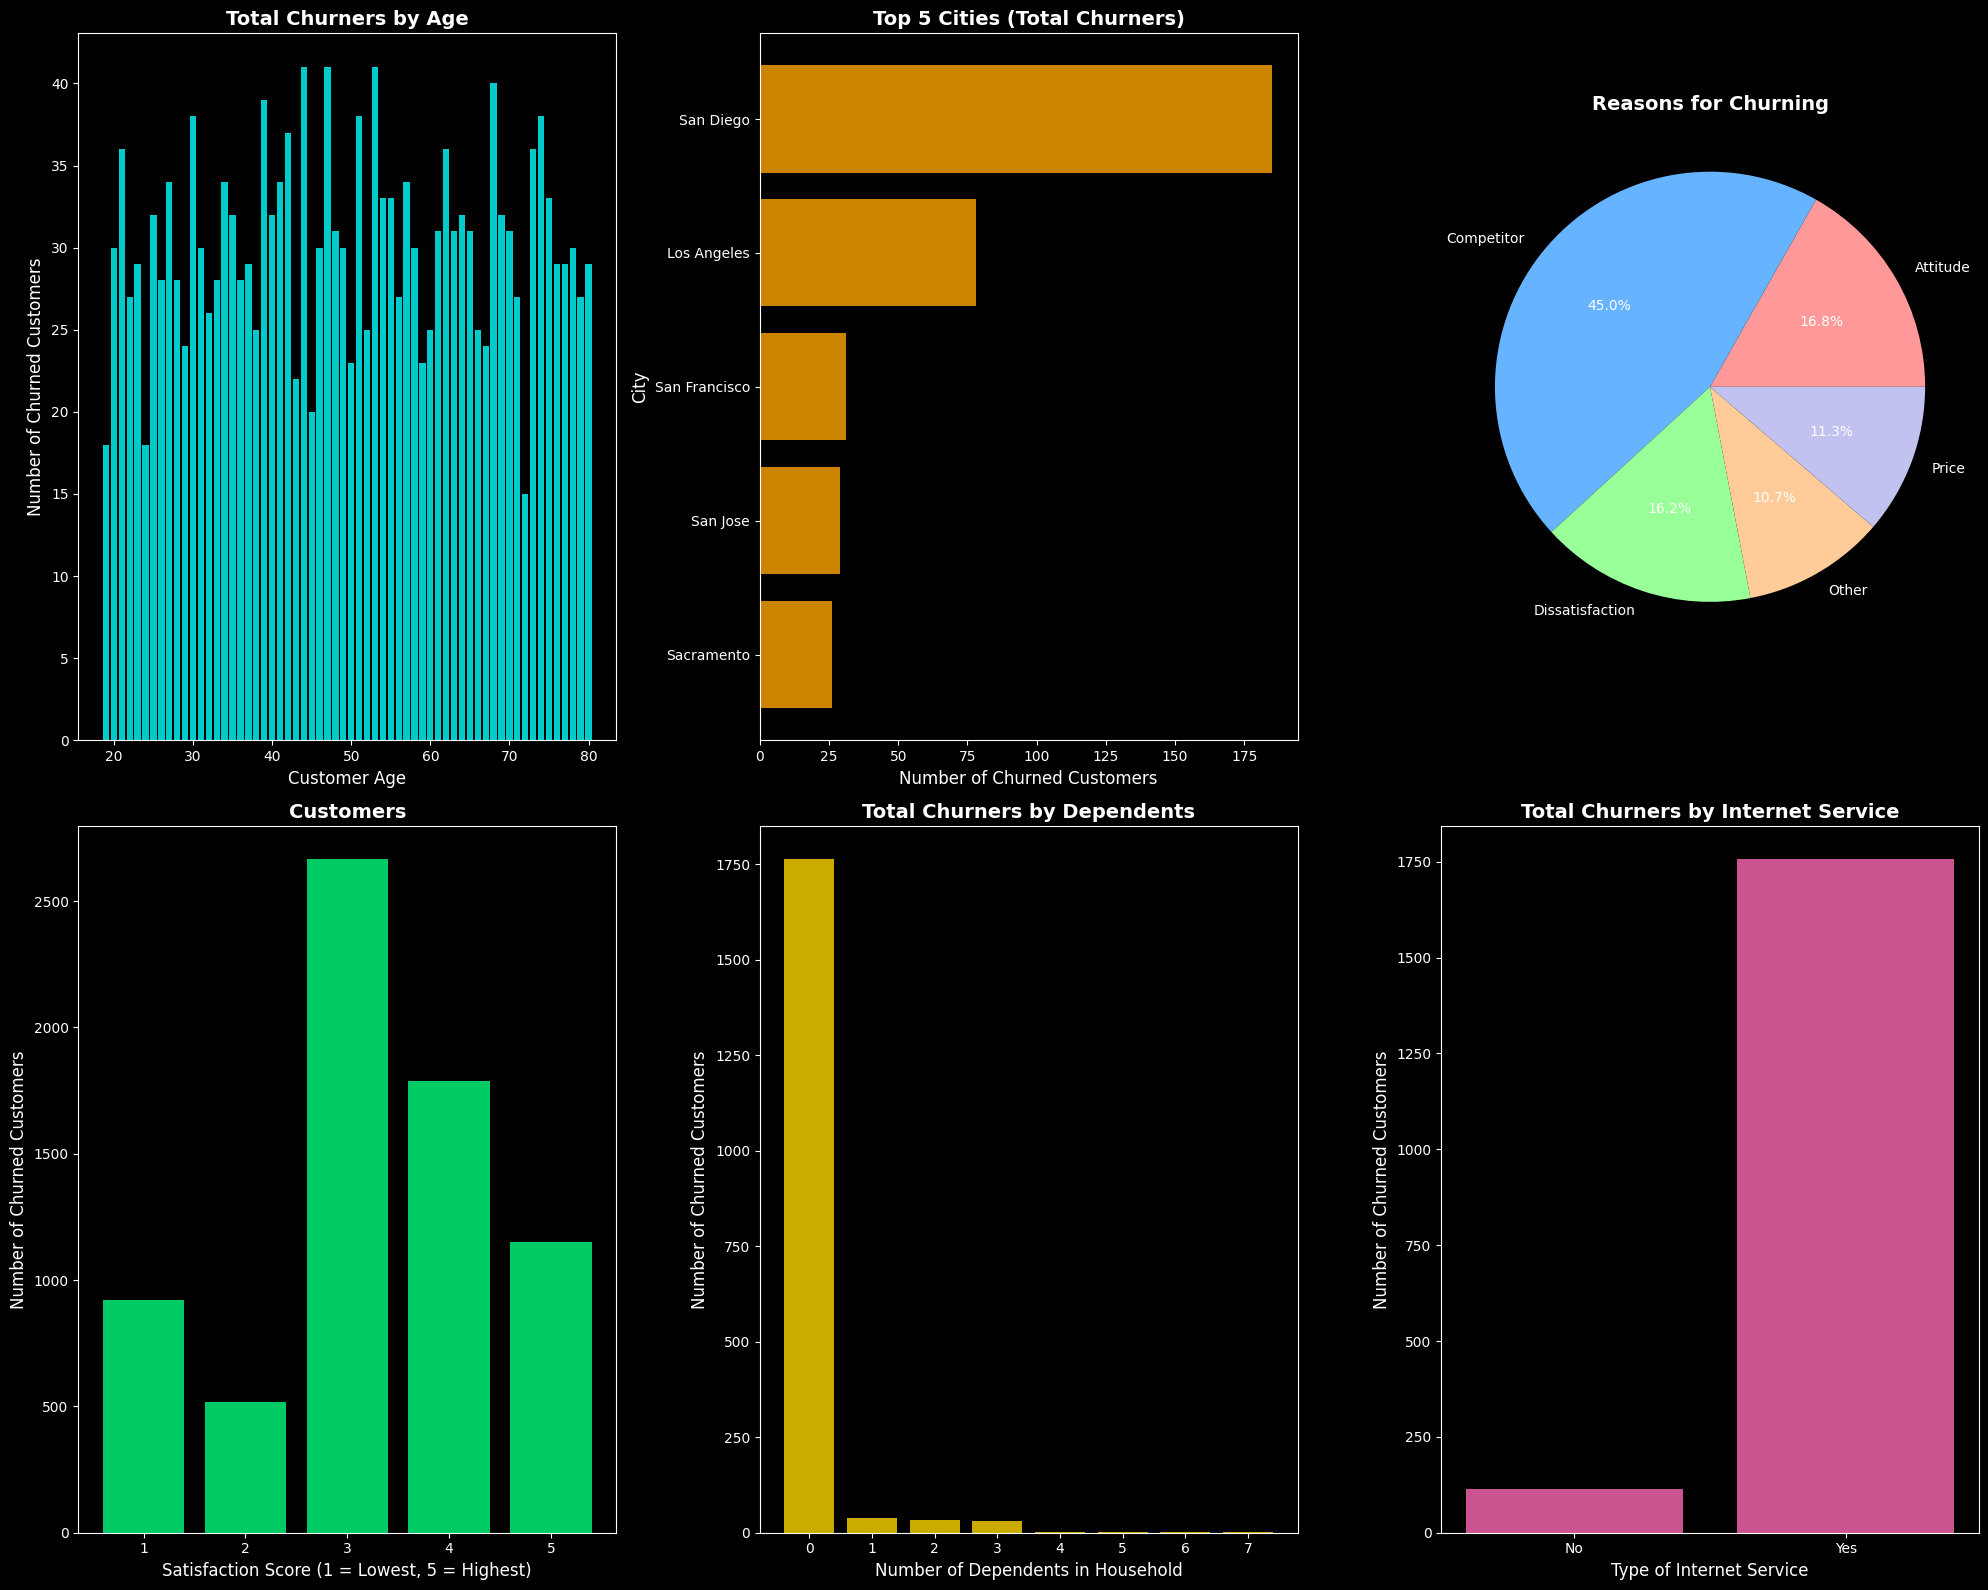

C:\Users\Abhirup Das\AppData\Local\Temp\ipykernel_15344\1239371476.py:65: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df[input_cols].select_dtypes(include='object').columns.tolist()


              precision    recall  f1-score   support

           0       0.94      0.82      0.87      1035
           1       0.63      0.85      0.72       374

    accuracy                           0.83      1409
   macro avg       0.78      0.83      0.80      1409
weighted avg       0.86      0.83      0.83      1409



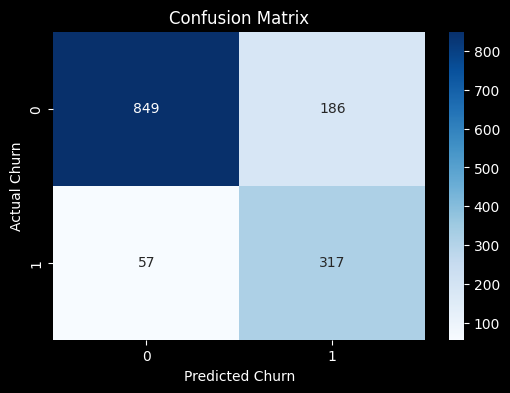

C:\Users\Abhirup Das\AppData\Local\Temp\ipykernel_15344\1239371476.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.tail(10), x='Importance', y='Feature', palette='magma')


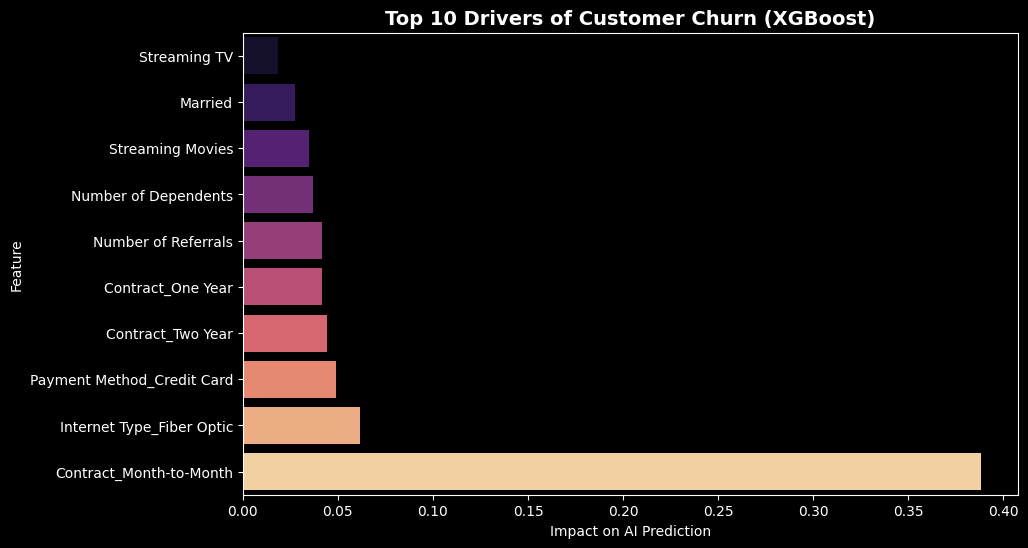

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
df = pd.read_csv('../data/telco.csv')

df = df.drop(columns = ['Quarter','Gender','Total Charges','Churn Reason','Customer Status','State',
                   'Zip Code','Latitude','Longitude','Country', 'Total Refunds', 
                   'Total Extra Data Charges', 'Total Long Distance Charges', 'Total Revenue',
                   'Under 30', 'Senior Citizen', 'Referred a Friend', 'Dependents',
                   'CLTV','Customer ID'] , errors = 'ignore')
##EDA: Age,City,Churn Category,Satisfaction Score, Number Of Dependents,Internet Service
age_churn = df[df['Churn Label'] == 'Yes'].groupby('Age')['Churn Label'].count()
city_churn = df[df['Churn Label'] == 'Yes'].groupby('City')['Churn Label'].count().sort_values(ascending=True).tail(5)
churn_cats_count = df[df['Churn Label'] == 'Yes'].groupby('Churn Category')['Churn Label'].count()
satisfied = df['Satisfaction Score'].value_counts().sort_index()
dependents = df[df['Churn Label'] == 'Yes'].groupby('Number of Dependents')['Churn Label'].count()
internet = df[df['Churn Label'] == 'Yes'].groupby('Internet Service')['Churn Label'].count()

plt.style.use('dark_background')
figure , axes = plt.subplots(2 , 3 , figsize = (20,16))
axes[0,0].bar(age_churn.index, age_churn.values, color='cyan', alpha=0.8)
axes[0,0].set_title('Total Churners by Age', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Customer Age', fontsize=12)
axes[0,0].set_ylabel('Number of Churned Customers', fontsize=12)

axes[0,1].barh(city_churn.index, city_churn.values, color='orange', alpha=0.8)
axes[0,1].set_title('Top 5 Cities (Total Churners)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Number of Churned Customers', fontsize=12)
axes[0,1].set_ylabel('City', fontsize=12)

axes[0,2].pie(churn_cats_count, labels=churn_cats_count.index, autopct='%1.1f%%', 
              colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])
axes[0,2].set_title('Reasons for Churning', fontsize=14, fontweight='bold')

axes[1,0].bar(satisfied.index, satisfied.values, color='springgreen', alpha=0.8)
axes[1,0].set_title('Customers', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Satisfaction Score (1 = Lowest, 5 = Highest)', fontsize=12)
axes[1,0].set_ylabel('Number of Churned Customers', fontsize=12)
axes[1,0].set_xticks([1, 2, 3, 4, 5])

axes[1,1].bar(dependents.index, dependents.values, color='gold', alpha=0.8)
axes[1,1].set_title('Total Churners by Dependents', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Number of Dependents in Household', fontsize=12)
axes[1,1].set_ylabel('Number of Churned Customers', fontsize=12)
axes[1,1].set_xticks(dependents.index)

axes[1,2].bar(internet.index, internet.values, color='hotpink', alpha=0.8)
axes[1,2].set_title('Total Churners by Internet Service', fontsize=14, fontweight='bold')
axes[1,2].set_xlabel('Type of Internet Service', fontsize=12)
axes[1,2].set_ylabel('Number of Churned Customers', fontsize=12) 

plt.tight_layout()
plt.show()
#print(df['Churn Label'].value_counts()) No:5174  Yes:1869
input_cols = ['Age','Married','Number of Dependents','Population','Number of Referrals',
              'Tenure in Months','Offer','Phone Service','Avg Monthly Long Distance Charges',
              'Multiple Lines','Internet Service','Internet Type','Avg Monthly GB Download',
              'Online Security','Online Backup','Device Protection Plan','Premium Tech Support',
              'Streaming TV','Streaming Movies','Streaming Music','Unlimited Data','Contract',
              'Paperless Billing','Payment Method','Monthly Charge']
df['Churn Label'] = df['Churn Label'].map({'Yes': 1, 'No': 0})
numeric_cols = df[input_cols].select_dtypes(include = np.number).columns.tolist()
categorical_cols = df[input_cols].select_dtypes(include='object').columns.tolist()
binary_cols = []
categorical_cols_final = []
target_col = 'Churn Label'
for i in categorical_cols :
    if df[i].nunique() == 2 :
        binary_cols.append(i)
    else:
        categorical_cols_final.append(i)
df[binary_cols] = np.where(df[binary_cols] == 'Yes', 1, 0)
numeric_cols.extend(binary_cols)
for col in categorical_cols_final:
    df[col] = df[col].fillna('None')
#splitting(training and test set because we use GridSearchCV to handle validation)
from sklearn.model_selection import train_test_split
train_df , test_df = train_test_split(df,test_size=0.2,random_state=42,stratify=df['Churn Label'])

#imputing 
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
imputer.fit(train_df[numeric_cols])
train_df[numeric_cols] = imputer.transform(train_df[numeric_cols])
test_df[numeric_cols] = imputer.transform(test_df[numeric_cols])
#scaling
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(train_df[numeric_cols])
train_df[numeric_cols] = scaler.transform(train_df[numeric_cols])
test_df[numeric_cols] = scaler.transform(test_df[numeric_cols])
#onehot encoding
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False , handle_unknown='ignore')
encoder.fit(train_df[categorical_cols_final])
encoded_cols = encoder.get_feature_names_out(categorical_cols_final)
train_df[encoded_cols] = encoder.transform(train_df[categorical_cols_final])
test_df[encoded_cols] = encoder.transform(test_df[categorical_cols_final])

#model
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report , confusion_matrix
# params = {'max_depth' : [ 5,7,9,12],
#             'n_estimators': [100,200,300,400],
#             'learning_rate': [0.05 , 0.1 , 0.2 , 0.3],
#             'scale_pos_weight' : [2.75 , 2.76 , 2.77 , 2.777]}
# model = XGBClassifier( n_jobs = -1 , random_state = 42 )
# grid_search  =  GridSearchCV(estimator=model, param_grid=params, scoring='f1', cv=3)
# grid_search.fit(train_df[numeric_cols + list(encoded_cols)], train_df[target_col])
# print(grid_search.best_params_) --> output: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'scale_pos_weight': 2.75}
model = XGBClassifier( n_jobs = -1 , random_state = 42, learning_rate=0.05 , max_depth=5, n_estimators=200 ,scale_pos_weight = 2.75 )
model.fit(train_df[numeric_cols + list(encoded_cols)], train_df[target_col])
preds_test = model.predict(test_df[numeric_cols + list(encoded_cols)])
#evaluation
print(classification_report(test_df[target_col], preds_test))

plt.figure(figsize=(6,4))
cm = confusion_matrix(test_df[target_col], preds_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Churn')
plt.xlabel('Predicted Churn')
plt.show()
#importance
importances = model.feature_importances_
feature_names = numeric_cols + encoded_cols.tolist() 
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

#top 10
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.tail(10), x='Importance', y='Feature', palette='magma')
plt.title('Top 10 Drivers of Customer Churn (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Impact on AI Prediction')
plt.ylabel('Feature')
plt.show()





